In [ ]:
!pip install xgboost -q


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\S8654134\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\S8654134\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [7]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 599.9 kB/s eta 0:00:13
   -- ------------------------------------- 0.5/8.2 MB 599.9 kB/s eta 0:00:13
   --- ------------------------------------ 0.8/8.2 MB 588.4 kB/s eta 0:00:13
   --- ------------------------------------ 0.8/8.2 MB 588.4 kB/s eta 0:00:13
   --- ------------------------------------ 0.8/8.2 MB 588.4 kB/s eta 0:00:13
   ----- ---------------------------------- 1.0/8.2 MB 592.2 kB/s eta 0:00:13
   ----- -------------------------------


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\S8654134\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [9]:
pip install numpy pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\S8654134\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

np.random.seed(42)
print("Bibliothèques importées avec succès.")

Bibliothèques importées avec succès.


In [25]:
# ============================================================
# GÉNÉRATION D'UN JEU DE DONNÉES SIMULÉ RÉALISTE — 5 ANS
# ============================================================
np.random.seed(42)

# 5 ans de fonctionnement continu, mesure horaire
n_hours = 5 * 365 * 24   # = 43 800 heures

# --- Signaux de base (fonctionnement normal + bruit) ---
temperature = np.random.normal(1550, 5, n_hours)
pression     = np.random.normal(1.02, 0.01, n_hours)
vibration    = np.random.normal(2.5, 0.2, n_hours)
debit_gaz    = np.random.normal(900, 15, n_hours)

cible = np.zeros(n_hours)
duree_derive = 200  # ~1 semaine de dérive avant panne

# --- GÉNÉRATION AUTOMATIQUE DES PANNES ---
# On veut en moyenne 1 panne tous les ~2 mois (réaliste pour un équipement suivi)
intervalle_moyen = 1500   # heures entre deux pannes (~2 mois)
types_panne = ["vibration", "temperature", "mixte"]

pannes = []
h = 2000  # première panne après 2000h (rodage)
while h < n_hours - duree_derive:
    type_choisi = np.random.choice(types_panne)
    pannes.append({"h": h, "type": type_choisi})
    # intervalle aléatoire autour de la moyenne (plus réaliste)
    h += int(np.random.normal(intervalle_moyen, 400))
    if h < duree_derive:
        h = duree_derive + 100

print(f"Nombre de pannes générées : {len(pannes)}")

# --- Application des dérives avant chaque panne ---
for p in pannes:
    h = p["h"]
    debut = h - duree_derive
    if debut < 0:
        continue
    ramp = np.linspace(0, 1, duree_derive)
    bruit = np.random.normal(0, 0.15, duree_derive)
    ramp_bruite = np.clip(ramp + bruit, 0, 1.3)

    if p["type"] == "vibration":
        vibration[debut:h] += ramp_bruite * 3.0
        temperature[debut:h] += ramp_bruite * 5.0
    elif p["type"] == "temperature":
        temperature[debut:h] += ramp_bruite * 25.0
        debit_gaz[debut:h] += ramp_bruite * 40.0
    elif p["type"] == "mixte":
        vibration[debut:h] += ramp_bruite * 2.0
        temperature[debut:h] += ramp_bruite * 15.0
        debit_gaz[debut:h] += np.random.normal(0, 25, duree_derive)

    debut_alerte = max(0, h - 48)
    cible[debut_alerte:h] = 1

# --- FAUSSES DÉRIVES (pièges : ça monte mais PAS de panne) ---
# On en met environ autant que de vraies pannes, réparties aléatoirement
n_fausses = len(pannes)
positions_fausses = np.random.randint(300, n_hours, n_fausses)
for h in positions_fausses:
    debut = h - 150
    if debut < 0:
        continue
    # On évite de tomber pile sur une vraie zone de panne
    if cible[debut:h].sum() > 0:
        continue
    ramp = np.linspace(0, 1, 150)
    vibration[debut:h] += ramp * 1.8
    temperature[debut:h] += ramp * 8.0

# --- Construction du DataFrame ---
df = pd.DataFrame({
    'temperature': temperature,
    'pression': pression,
    'vibration': vibration,
    'debit_gaz': debit_gaz,
    'panne_48h': cible.astype(int)
})

print(df.head())
print(f"\nNombre total d'observations : {len(df)} heures (~5 ans)")
print(f"Nombre de vraies pannes : {len(pannes)}")
print(f"Nombre de fausses dérives : {n_fausses}")
print(f"Proportion de panne_48h = 1 : {df['panne_48h'].mean()*100:.2f}%")
print(f"Nombre d'heures 'panne imminente' : {int(df['panne_48h'].sum())}")

Nombre de pannes générées : 30
   temperature  pression  vibration   debit_gaz  panne_48h
0  1552.483571  1.031361   2.425663  896.171441          0
1  1549.308678  1.026514   2.324398  924.631437          0
2  1553.238443  1.015793   2.576006  910.524005          0
3  1557.615149  1.028028   2.605922  923.712433          0
4  1548.829233  1.040819   2.347280  885.819707          0

Nombre total d'observations : 43800 heures (~5 ans)
Nombre de vraies pannes : 30
Nombre de fausses dérives : 30
Proportion de panne_48h = 1 : 3.29%
Nombre d'heures 'panne imminente' : 1440


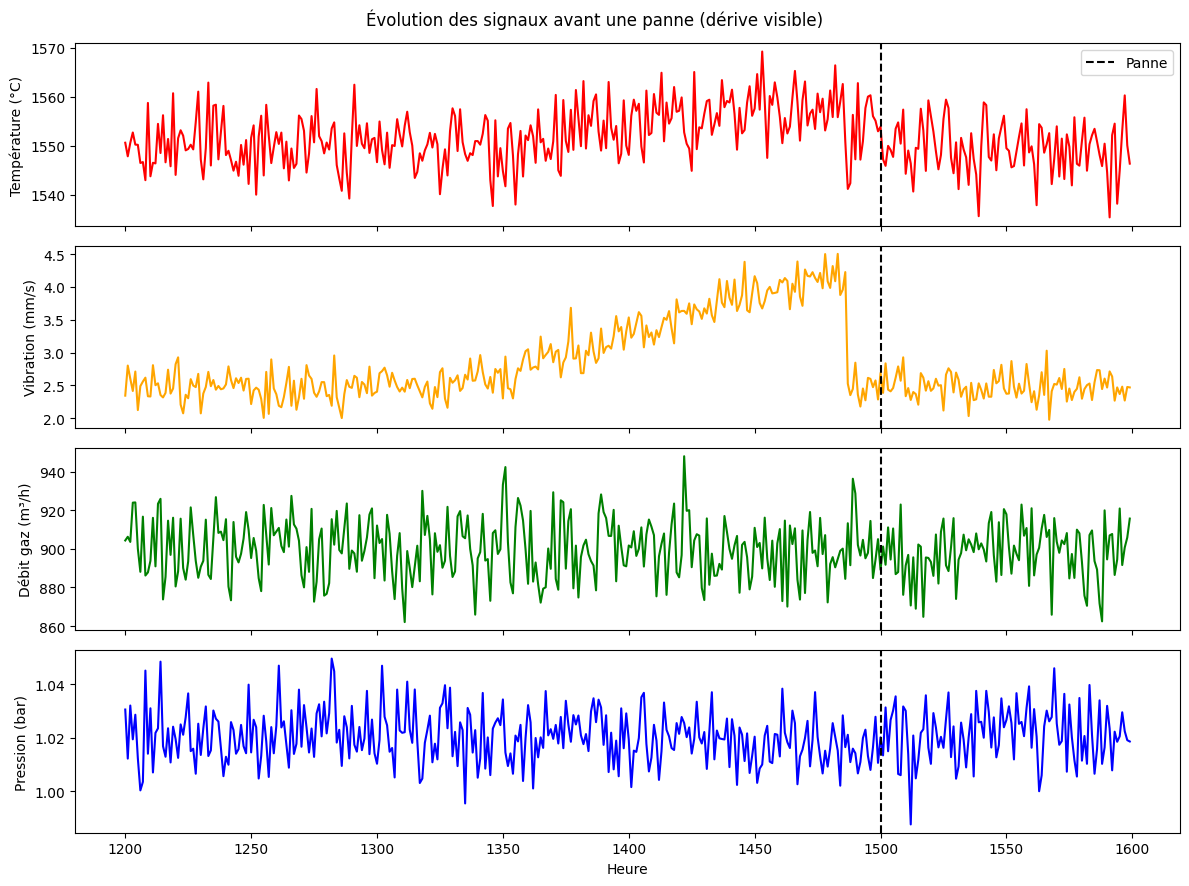

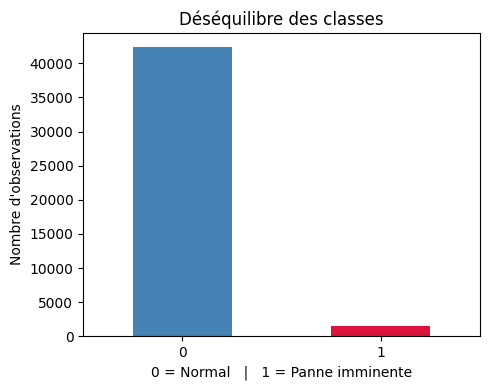

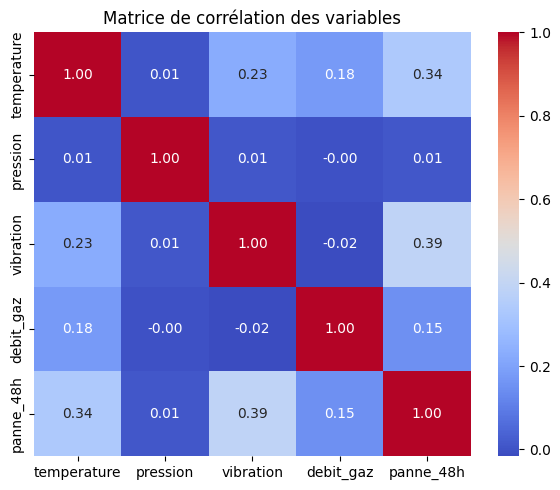

        temperature      pression     vibration     debit_gaz     panne_48h
count  43800.000000  43800.000000  43800.000000  43800.000000  43800.000000
mean    1551.379070      1.020046      2.688565    901.121900      0.032877
std        6.327837      0.010020      0.580817     16.421178      0.178316
min     1528.523045      0.975370      1.700134    793.777770      0.000000
25%     1547.236137      1.013332      2.390539    890.243170      0.000000
50%     1550.857263      1.020078      2.541830    900.737786      0.000000
75%     1554.749075      1.026796      2.720773    911.441615      0.000000
max     1592.326986      1.058298      7.020931    987.811441      1.000000


In [26]:
# ============================================================
# ANALYSE EXPLORATOIRE DES DONNÉES (EDA)
# ============================================================

# 1) Visualisation des signaux dans le temps (zoom sur une panne)
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
zone = slice(1200, 1600)  # autour de la 1ère panne (h=1500)

axes[0].plot(range(1200,1600), df['temperature'][zone], color='red')
axes[0].set_ylabel('Température (°C)')
axes[0].axvline(1500, color='black', linestyle='--', label='Panne')
axes[0].legend()

axes[1].plot(range(1200,1600), df['vibration'][zone], color='orange')
axes[1].set_ylabel('Vibration (mm/s)')
axes[1].axvline(1500, color='black', linestyle='--')

axes[2].plot(range(1200,1600), df['debit_gaz'][zone], color='green')
axes[2].set_ylabel('Débit gaz (m³/h)')
axes[2].axvline(1500, color='black', linestyle='--')

axes[3].plot(range(1200,1600), df['pression'][zone], color='blue')
axes[3].set_ylabel('Pression (bar)')
axes[3].set_xlabel('Heure')
axes[3].axvline(1500, color='black', linestyle='--')

plt.suptitle("Évolution des signaux avant une panne (dérive visible)")
plt.tight_layout()
plt.show()

# 2) Déséquilibre des classes
plt.figure(figsize=(5,4))
df['panne_48h'].value_counts().plot(kind='bar', color=['steelblue','crimson'])
plt.title("Déséquilibre des classes")
plt.xlabel("0 = Normal   |   1 = Panne imminente")
plt.ylabel("Nombre d'observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 3) Heatmap de corrélation
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matrice de corrélation des variables")
plt.tight_layout()
plt.show()

# 4) Statistiques descriptives
print(df.describe())

In [27]:
# ============================================================
# SÉPARATION TRAIN / TEST (SPLIT TEMPOREL)
# ============================================================
# IMPORTANT : sur des données temporelles, on n'utilise PAS de split aléatoire
# (risque de fuite de données). On prend les 80% premières heures pour
# l'entraînement, les 20% suivantes pour le test.

X = df[['temperature', 'pression', 'vibration', 'debit_gaz']]
y = df['panne_48h']

split_index = int(len(df) * 0.80)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Entraînement : {len(X_train)} heures")
print(f"Test         : {len(X_test)} heures")
print(f"Pannes dans le test : {int(y_test.sum())}")

Entraînement : 35040 heures
Test         : 8760 heures
Pannes dans le test : 288


In [28]:
# ============================================================
# MODÉLISATION : 3 modèles comparés
# ============================================================

# --- Modèle 0 : BASELINE (régression logistique) ---
# Permet de vérifier que les modèles complexes apportent vraiment un gain.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

model_lr = LogisticRegression(class_weight='balanced', max_iter=1000)
model_lr.fit(X_train_sc, y_train)

# --- Modèle 1 : Random Forest ---
model_rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42
)
model_rf.fit(X_train, y_train)

# --- Modèle 2 : XGBoost ---
ratio = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
model_xgb = XGBClassifier(
    n_estimators=100, scale_pos_weight=ratio,
    eval_metric='logloss', random_state=42
)
model_xgb.fit(X_train, y_train)

print("Les 3 modèles sont entraînés.")

Les 3 modèles sont entraînés.


In [29]:
# ============================================================
# ÉVALUATION DES MODÈLES
# ============================================================
modeles = [
    ('Régression Logistique', model_lr, X_test_sc),
    ('Random Forest', model_rf, X_test),
    ('XGBoost', model_xgb, X_test),
]

resultats = []
for nom, modele, X_eval in modeles:
    y_pred = modele.predict(X_eval)
    y_proba = modele.predict_proba(X_eval)[:, 1]
    rapport = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)

    print(f"\n=== {nom} ===")
    print(classification_report(y_test, y_pred, digits=3, zero_division=0))
    print(f"ROC-AUC : {auc:.3f}")

    resultats.append({
        'Modèle': nom,
        'Precision': round(rapport['1']['precision'], 3),
        'Recall': round(rapport['1']['recall'], 3),
        'F1-score': round(rapport['1']['f1-score'], 3),
        'ROC-AUC': round(auc, 3),
    })

# Tableau récapitulatif
df_resultats = pd.DataFrame(resultats)
print("\n=== TABLEAU COMPARATIF ===")
print(df_resultats.to_string(index=False))


=== Régression Logistique ===
              precision    recall  f1-score   support

           0      0.998     0.927     0.961      8472
           1      0.303     0.938     0.458       288

    accuracy                          0.927      8760
   macro avg      0.651     0.932     0.710      8760
weighted avg      0.975     0.927     0.944      8760

ROC-AUC : 0.979

=== Random Forest ===
              precision    recall  f1-score   support

           0      0.984     0.988     0.986      8472
           1      0.602     0.514     0.554       288

    accuracy                          0.973      8760
   macro avg      0.793     0.751     0.770      8760
weighted avg      0.971     0.973     0.972      8760

ROC-AUC : 0.974

=== XGBoost ===
              precision    recall  f1-score   support

           0      0.988     0.978     0.983      8472
           1      0.504     0.663     0.573       288

    accuracy                          0.967      8760
   macro avg      0.746  

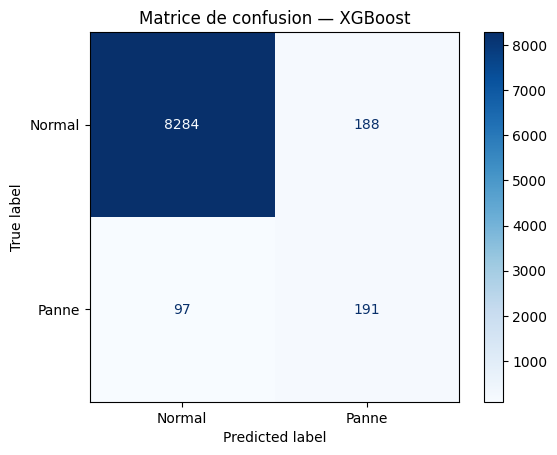

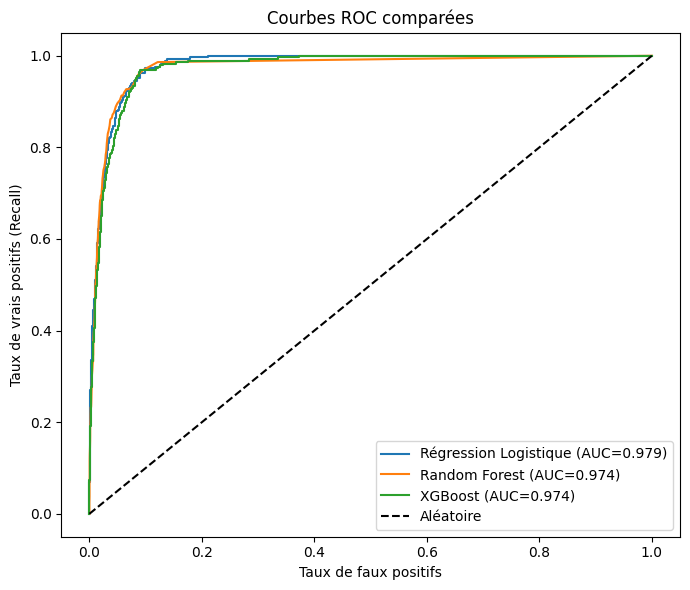

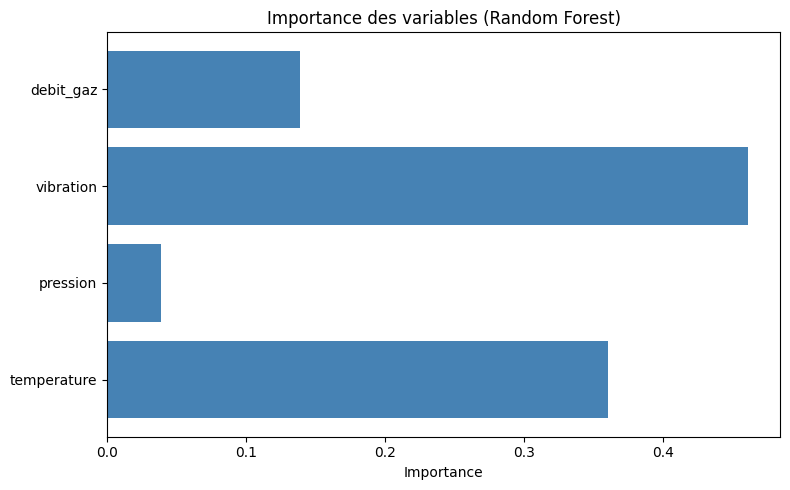

In [30]:
# ============================================================
# GRAPHIQUES DE RÉSULTATS
# ============================================================

# 1) Matrice de confusion (XGBoost)
y_pred_xgb = model_xgb.predict(X_test)
cm = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm, display_labels=['Normal','Panne']).plot(cmap='Blues')
plt.title("Matrice de confusion — XGBoost")
plt.show()

# 2) Courbes ROC des 3 modèles
plt.figure(figsize=(7,6))
for nom, modele, X_eval in modeles:
    y_proba = modele.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{nom} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],'k--', label='Aléatoire')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs (Recall)')
plt.title('Courbes ROC comparées')
plt.legend()
plt.tight_layout()
plt.show()

# 3) Importance des variables (Random Forest)
importances = model_rf.feature_importances_
plt.figure(figsize=(8,5))
plt.barh(X.columns, importances, color='steelblue')
plt.xlabel('Importance')
plt.title('Importance des variables (Random Forest)')
plt.tight_layout()
plt.show()

In [31]:
# ============================================================
# BONUS 1 : ANALYSE PAR ÉVÉNEMENT (et non par heure)
# ============================================================
# En réalité, ce qui compte pour l'usine n'est pas de détecter
# CHAQUE heure de panne, mais de détecter CHAQUE PANNE au moins
# une fois dans sa fenêtre d'alerte. C'est un KPI métier plus juste.

# On récupère les prédictions de XGBoost sur le test
y_pred_xgb = model_xgb.predict(X_test)

# On reconstruit les indices réels du test (split temporel)
test_start = split_index  # début du test dans le dataset complet
y_test_array = y_test.values
y_pred_array = y_pred_xgb

# --- Identifier les "épisodes" de panne dans le test ---
# Un épisode = suite continue d'heures où panne_48h == 1
episodes = []
in_episode = False
for i in range(len(y_test_array)):
    if y_test_array[i] == 1 and not in_episode:
        debut_ep = i
        in_episode = True
    elif y_test_array[i] == 0 and in_episode:
        episodes.append((debut_ep, i - 1))
        in_episode = False
if in_episode:
    episodes.append((debut_ep, len(y_test_array) - 1))

# --- Pour chaque épisode, vérifier s'il a été détecté au moins une fois ---
episodes_detectes = 0
for (debut, fin) in episodes:
    if y_pred_array[debut:fin+1].sum() > 0:  # au moins 1 alerte dans la fenêtre
        episodes_detectes += 1

n_episodes = len(episodes)
taux_detection_evenement = episodes_detectes / n_episodes * 100 if n_episodes > 0 else 0

print("=== ANALYSE PAR ÉVÉNEMENT (XGBoost) ===")
print(f"Nombre de pannes (épisodes) dans le test : {n_episodes}")
print(f"Pannes détectées au moins une fois        : {episodes_detectes}")
print(f"TAUX DE DÉTECTION PAR ÉVÉNEMENT            : {taux_detection_evenement:.1f}%")
print()
print("Interprétation : même si le modèle rate certaines HEURES de panne,")
print("il détecte la plupart des PANNES au moins une fois dans leur fenêtre de 48h,")
print("ce qui suffit en pratique pour déclencher une intervention.")

=== ANALYSE PAR ÉVÉNEMENT (XGBoost) ===
Nombre de pannes (épisodes) dans le test : 6
Pannes détectées au moins une fois        : 6
TAUX DE DÉTECTION PAR ÉVÉNEMENT            : 100.0%

Interprétation : même si le modèle rate certaines HEURES de panne,
il détecte la plupart des PANNES au moins une fois dans leur fenêtre de 48h,
ce qui suffit en pratique pour déclencher une intervention.


=== EFFET DU SEUIL DE DÉCISION (XGBoost) ===
 Seuil  Precision  Recall  F1-score  Fausses alertes (h)
   0.2      0.412   0.788     0.541                  324
   0.3      0.450   0.747     0.561                  263
   0.4      0.486   0.708     0.576                  216
   0.5      0.504   0.663     0.573                  188
   0.6      0.523   0.594     0.556                  156
   0.7      0.554   0.538     0.546                  125


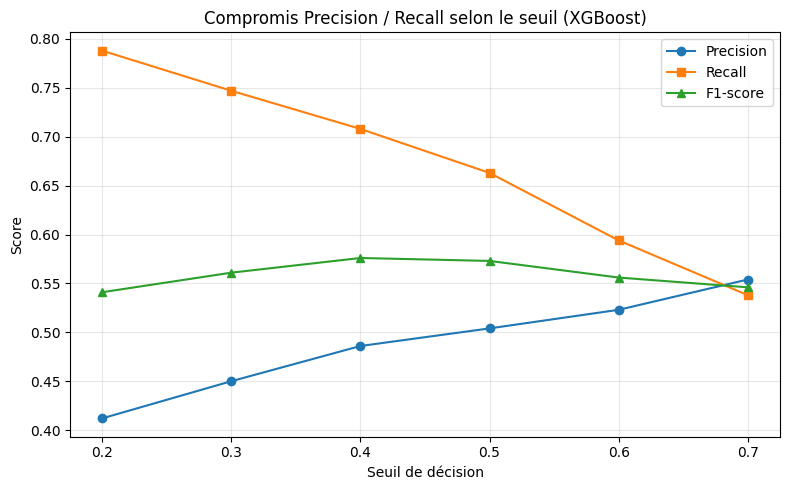

In [32]:
# ============================================================
# BONUS 2 : EFFET DU SEUIL DE DÉCISION (XGBoost)
# ============================================================
# Par défaut, le modèle alerte si probabilité > 0.5.
# En abaissant ce seuil, on détecte plus de pannes (recall ↑)
# mais on génère plus de fausses alertes (precision ↓).
# Ce tableau illustre le compromis que l'usine doit arbitrer.

from sklearn.metrics import precision_score, recall_score, f1_score

y_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

seuils = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
resultats_seuils = []

for s in seuils:
    y_pred_s = (y_proba_xgb >= s).astype(int)
    prec = precision_score(y_test, y_pred_s, zero_division=0)
    rec = recall_score(y_test, y_pred_s, zero_division=0)
    f1 = f1_score(y_test, y_pred_s, zero_division=0)
    # nombre de fausses alertes (heures)
    fp = ((y_pred_s == 1) & (y_test == 0)).sum()
    resultats_seuils.append({
        'Seuil': s,
        'Precision': round(prec, 3),
        'Recall': round(rec, 3),
        'F1-score': round(f1, 3),
        'Fausses alertes (h)': int(fp)
    })

df_seuils = pd.DataFrame(resultats_seuils)
print("=== EFFET DU SEUIL DE DÉCISION (XGBoost) ===")
print(df_seuils.to_string(index=False))

# Graphique du compromis precision/recall selon le seuil
plt.figure(figsize=(8,5))
plt.plot(df_seuils['Seuil'], df_seuils['Precision'], 'o-', label='Precision')
plt.plot(df_seuils['Seuil'], df_seuils['Recall'], 's-', label='Recall')
plt.plot(df_seuils['Seuil'], df_seuils['F1-score'], '^-', label='F1-score')
plt.xlabel('Seuil de décision')
plt.ylabel('Score')
plt.title('Compromis Precision / Recall selon le seuil (XGBoost)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()